# Binary Pass Classifier: Logistic Regression

Goal: build the first classification model where the features come from tracking data and the target is whether the frame is a pass event.

This is intentionally binary and simple before moving to a multi-class event model.

## Model Design

- Unit of observation: one reliable live-play tracking frame.
- Source table: Step 2 `master_join_table.parquet`.
- Features: tracking-derived numeric/boolean columns only, with feature lineage shown before training.
- Target: `is_pass = 1` when `event_label` contains a pass event type.
- Split: complete `match_id` holdout using `config.yaml`.
- Algorithm: logistic regression with median imputation, standard scaling, and balanced class weights.

In [1]:
from pathlib import Path
import os
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

os.environ.setdefault(
    'MPLCONFIGDIR',
    str(PROJECT_ROOT / '.matplotlib_cache'),
)

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

SRC_DIR = PROJECT_ROOT / 'src'
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from sklearn.metrics import average_precision_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import roc_curve

from driblab.config import CONFIG_PATH, MODEL_BASE_DATA_DIR
from driblab.config import PASS_CLASSIFIER_DATA_DIR
from driblab.config import PASS_CLASSIFIER_MODEL_DIR
from driblab.config import load_project_config
from driblab.evaluation.classification import binary_classification_metrics
from driblab.features.match_splits import load_match_splits
from driblab.features.match_splits import summarize_splits
from driblab.models.pass_classifier import PassModelConfig
from driblab.models.pass_classifier import build_pass_pipeline
from driblab.models.pass_classifier import describe_pass_features
from driblab.models.pass_classifier import prepare_pass_model_frame
from driblab.models.pass_classifier import predict_passes
from driblab.models.pass_classifier import run_pass_model

project_config = load_project_config(CONFIG_PATH)
PROJECT_ROOT

PosixPath('/Users/nataliaurrea/Documents/IE/MBDS/Term III/Driblab')

## 1. Load the Master Join Table

This table keeps all matches together. We do not split by rows because adjacent tracking frames from the same match are highly related.

In [2]:
master_join_path = MODEL_BASE_DATA_DIR / 'master_join_table.parquet'
master_join = pd.read_parquet(master_join_path)

print(f'Rows: {len(master_join):,}')
print(f'Columns: {master_join.shape[1]:,}')
print(f'Matches: {master_join["match_id"].astype(str).nunique():,}')

master_join[['match_id', 'frame_id', 'event_label']].head()

Rows: 1,197,870
Columns: 86
Matches: 33


,match_id,frame_id,event_label
0,678949,24,no event
1,678949,25,no event
2,678949,26,no event
3,678949,27,no event
4,678949,28,no event


## 2. Create Target and Train/Validation/Test Split

`is_pass` is the binary target. The split comes from `config.yaml` and is applied by complete match ID.

In [3]:
splits_path = CONFIG_PATH
splits = load_match_splits(splits_path)
pass_config = project_config['pass_model']
model_frame, feature_columns = prepare_pass_model_frame(
    master_join,
    splits,
    positive_labels=tuple(pass_config['positive_labels']),
    configured_features=tuple(pass_config['feature_columns']),
)

print(f'Feature columns: {len(feature_columns)}')
print(feature_columns)

summarize_splits(model_frame)

Feature columns: 29
['period_id', 'match_clock_min', 'match_clock_sec', 'tracking_match_clock_seconds', 'cam_present', 'ball_x_raw', 'ball_y_raw', 'ball_z_m_raw', 'ball_x', 'ball_y', 'ball_z_m', 'ball_present_raw', 'ball_interpolated', 'dt_sec', 'ball_speed_xy_mps', 'ball_speed_mps', 'ball_acceleration_mps2', 'nearest_player_visible', 'nearest_player_distance_to_ball_m', 'has_possession', 'player_count', 'visible_player_count', 'mean_player_speed_mps', 'max_player_speed_mps', 'mean_reliable_player_speed_mps', 'max_reliable_player_speed_mps', 'min_distance_to_ball_m', 'mean_distance_to_ball_m', 'visible_player_share']


,data_split,rows,matches
0,test,177302,5
1,train,836384,23
2,validation,184184,5


## 2.1 Identify Feature Origins

All pass-model input features are read from the Step 2 master join table. This table separates fields that were kept from the original join from fields calculated or transformed during Step 2. The target and predictions are created later and are not input features.

In [4]:
feature_lineage = describe_pass_features(feature_columns)

feature_lineage

,feature,source_table,feature_kind,created_or_calculated,description
0,period_id,master_join_table.parquet,original master-join column,No,Match period kept from the tracking/event join.
1,match_clock_min,master_join_table.parquet,original master-join column,No,Minute component kept from the tracking clock.
2,match_clock_sec,master_join_table.parquet,original master-join column,No,Second component kept from the tracking clock.
3,tracking_match_clock_seconds,master_join_table.parquet,calculated master-join feature,Yes,Continuous 10 Hz time from clock and frame order.
4,cam_present,master_join_table.parquet,original master-join column,No,Tracking camera/live-play availability flag.
5,ball_x_raw,master_join_table.parquet,transformed master-join column,Transformed,Raw tracking ball x converted from meters to 0...
6,ball_y_raw,master_join_table.parquet,transformed master-join column,Transformed,Raw tracking ball y converted from meters to 0...
7,ball_z_m_raw,master_join_table.parquet,original master-join column,No,Raw tracking ball height kept in meters.
8,ball_x,master_join_table.parquet,calculated master-join feature,Yes,Normalized ball x after short-gap interpolation.
9,ball_y,master_join_table.parquet,calculated master-join feature,Yes,Normalized ball y after short-gap interpolation.


In [5]:
target_summary = (
    model_frame.groupby('data_split')
    .agg(
        rows=('is_pass', 'size'),
        pass_rows=('is_pass', 'sum'),
        pass_rate=('is_pass', 'mean'),
        matches=('match_id', lambda values: values.astype(str).nunique()),
    )
    .reset_index()
)

target_summary

,data_split,rows,pass_rows,pass_rate,matches
0,test,177302,3785,0.021348,5
1,train,836384,16175,0.019339,23
2,validation,184184,3579,0.019432,5


## 3. Train Logistic Regression

The model uses only the `train` matches. Validation and test matches are held out by match ID.

In [6]:
config = PassModelConfig(
    input_table=master_join_path,
    metrics_dir=PASS_CLASSIFIER_DATA_DIR,
    model_dir=PASS_CLASSIFIER_MODEL_DIR,
    match_splits=splits_path,
    threshold=float(pass_config['threshold']),
    c_value=float(pass_config['c_value']),
    max_iter=int(pass_config['max_iter']),
    solver=str(pass_config['solver']),
    random_state=int(pass_config['random_state']),
    class_weight=pass_config['class_weight'],
    positive_labels=tuple(pass_config['positive_labels']),
    feature_columns=tuple(pass_config['feature_columns']),
)

train_rows = model_frame[model_frame['data_split'].eq('train')]

pipeline = build_pass_pipeline(config)
pipeline.fit(train_rows[feature_columns], train_rows['is_pass'])

pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](29,)","['period_id','match_clock_min','match_clock_sec',..., 'min_distance_to_ball_m','mean_distance_to_ball_m','visible_player_share']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,29
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to repl

## 4. Evaluate the Model

We report accuracy, precision, recall, F1, and ROC-AUC for train, validation, and test. ROC-AUC uses the predicted probability, while the other metrics use the selected probability threshold.

In [7]:
predictions = predict_passes(
    model_frame=model_frame,
    feature_columns=feature_columns,
    pipeline=pipeline,
    threshold=config.threshold,
)

metric_rows = []
for split_name in ['train', 'validation', 'test']:
    split_rows = predictions[predictions['data_split'].eq(split_name)]
    metric_rows.append(
        binary_classification_metrics(
            y_true=split_rows['is_pass'],
            y_pred=split_rows['pass_prediction'],
            y_score=split_rows['pass_probability'],
            split_name=split_name,
        )
    )

metrics = pd.DataFrame(metric_rows)
metrics

,split,rows,positive_rows,positive_rate,accuracy,precision,recall,f1,roc_auc
0,train,836384,16175,0.019339,0.521494,0.025081,0.626955,0.048233,0.590642
1,validation,184184,3579,0.019432,0.483690,0.023830,0.639844,0.045949,0.577013
2,test,177302,3785,0.021348,0.495635,0.026558,0.634610,0.050982,0.578771


In [8]:
test_predictions = predictions[predictions['data_split'].eq('test')]
pd.crosstab(
    test_predictions['is_pass'],
    test_predictions['pass_prediction'],
    rownames=['actual_is_pass'],
    colnames=['predicted_is_pass'],
)

predicted_is_pass,0,1
actual_is_pass,,
0,85475,88042
1,1383,2402


## 5. Evaluation Graphs

The tables above give the exact metric values. The plots below make the model behavior easier to compare across splits and thresholds.


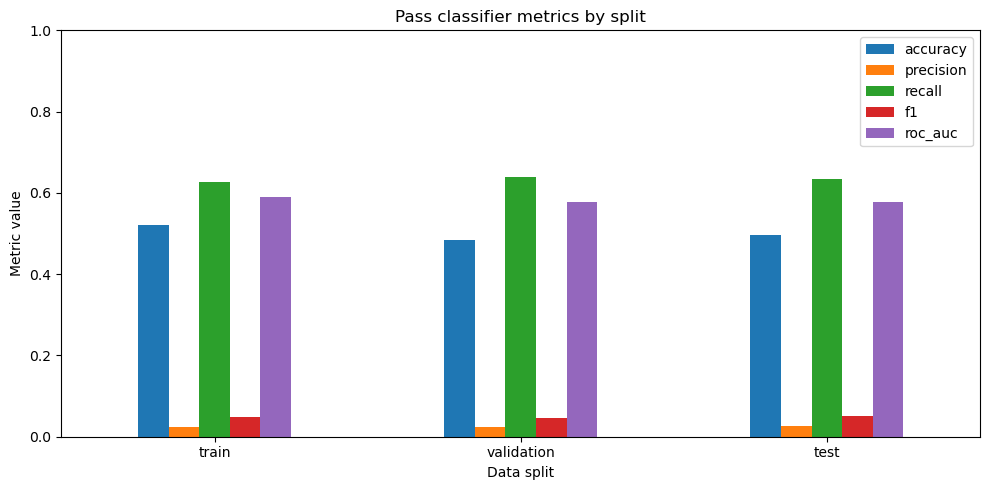

In [9]:
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
plot_metrics = metrics.set_index('split')[metric_cols]

fig, ax = plt.subplots(figsize=(10, 5))
plot_metrics.plot(kind='bar', ax=ax)
ax.set_title('Pass classifier metrics by split')
ax.set_xlabel('Data split')
ax.set_ylabel('Metric value')
ax.set_ylim(0, 1)
ax.legend(loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


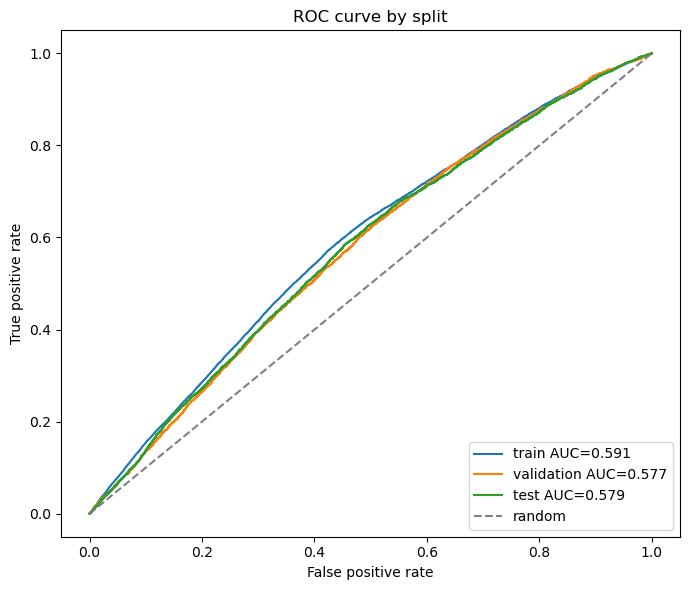

In [10]:
fig, ax = plt.subplots(figsize=(7, 6))

for split_name in ['train', 'validation', 'test']:
    split_rows = predictions[predictions['data_split'].eq(split_name)]
    fpr, tpr, _ = roc_curve(
        split_rows['is_pass'],
        split_rows['pass_probability'],
    )
    auc_value = metrics.loc[
        metrics['split'].eq(split_name),
        'roc_auc',
    ].iloc[0]
    ax.plot(fpr, tpr, label=f'{split_name} AUC={auc_value:.3f}')

ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='random')
ax.set_title('ROC curve by split')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()


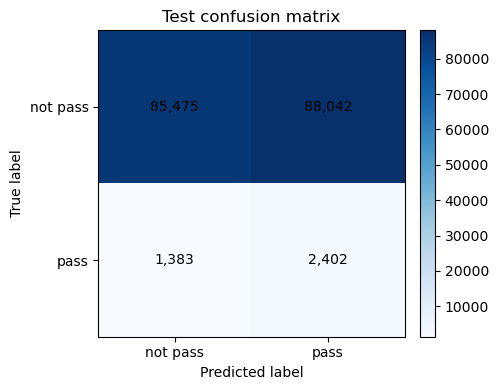

In [12]:
test_confusion = confusion_matrix(
    test_predictions['is_pass'],
    test_predictions['pass_prediction'],
    labels=[0, 1],
)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(test_confusion, cmap='Blues')
ax.set_title('Test confusion matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticks([0, 1], labels=['not pass', 'pass'])
ax.set_yticks([0, 1], labels=['not pass', 'pass'])

for row in range(test_confusion.shape[0]):
    for col in range(test_confusion.shape[1]):
        ax.text(
            col,
            row,
            f'{test_confusion[row, col]:,}',
            ha='center',
            va='center',
            color='black',
        )

fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()


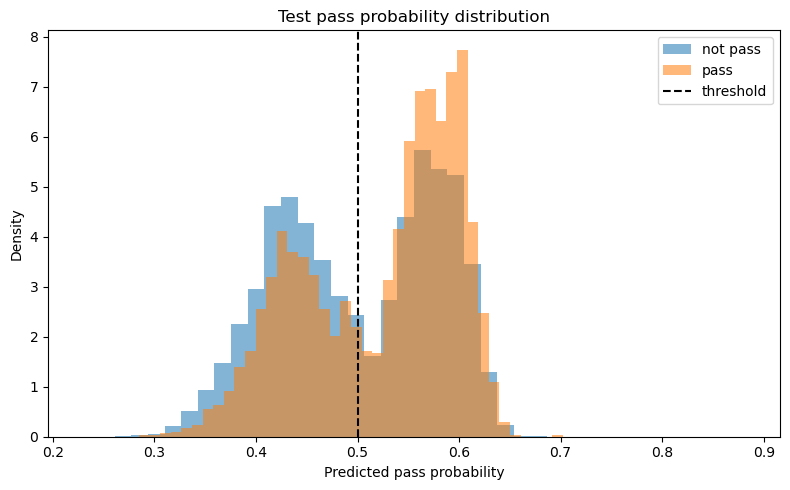

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))

for label_value, label_name in [(0, 'not pass'), (1, 'pass')]:
    values = test_predictions.loc[
        test_predictions['is_pass'].eq(label_value),
        'pass_probability',
    ]
    ax.hist(values, bins=40, alpha=0.55, density=True, label=label_name)

ax.axvline(config.threshold, color='black', linestyle='--', label='threshold')
ax.set_title('Test pass probability distribution')
ax.set_xlabel('Predicted pass probability')
ax.set_ylabel('Density')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Inspect Model Coefficients

Because the model is logistic regression with standardized numeric features, larger absolute coefficients show which tracking features the model uses most.


In [14]:
log_reg = pipeline.named_steps['model']
coef_table = pd.DataFrame(
    {
        'feature': feature_columns,
        'coefficient': log_reg.coef_[0],
    }
)
coef_table['abs_coefficient'] = coef_table['coefficient'].abs()
coef_table = coef_table.merge(
    feature_lineage[
        ['feature', 'feature_kind', 'created_or_calculated']
    ],
    on='feature',
    how='left',
)
coef_table.sort_values('abs_coefficient', ascending=False).head(20)

,feature,coefficient,abs_coefficient,feature_kind,created_or_calculated
15,ball_speed_mps,-0.129177,0.129177,calculated master-join feature,Yes
14,ball_speed_xy_mps,-0.113922,0.113922,calculated master-join feature,Yes
1,match_clock_min,-0.105615,0.105615,original master-join column,No
3,tracking_match_clock_seconds,-0.105393,0.105393,calculated master-join feature,Yes
0,period_id,-0.093341,0.093341,original master-join column,No
11,ball_present_raw,0.091120,0.091120,calculated master-join feature,Yes
27,mean_distance_to_ball_m,0.058883,0.058883,calculated master-join feature,Yes
16,ball_acceleration_mps2,0.058644,0.058644,calculated master-join feature,Yes
20,player_count,0.057761,0.057761,calculated master-join feature,Yes
22,mean_player_speed_mps,0.056417,0.056417,calculated master-join feature,Yes


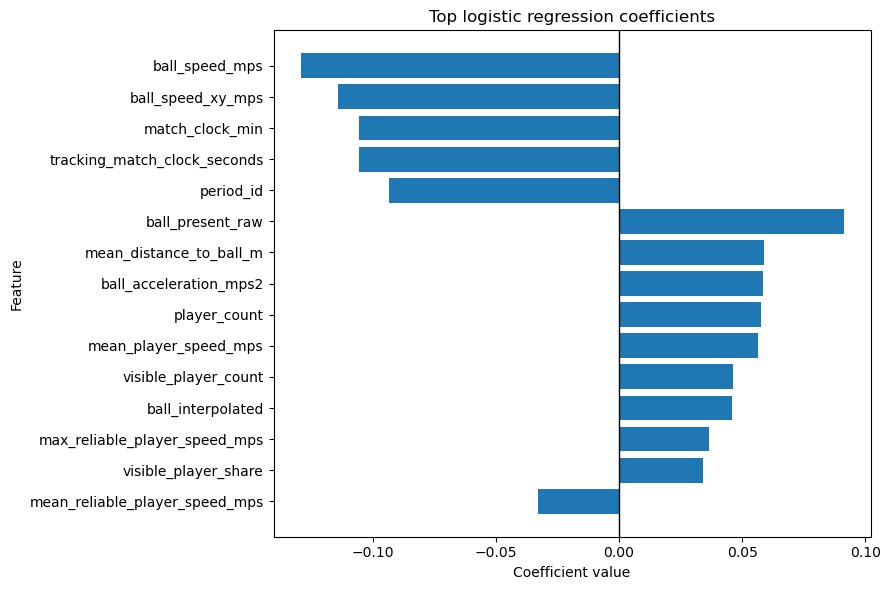

In [15]:
top_coefficients = (
    coef_table.sort_values('abs_coefficient', ascending=False)
    .head(15)
    .sort_values('abs_coefficient')
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_coefficients['feature'], top_coefficients['coefficient'])
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Top logistic regression coefficients')
ax.set_xlabel('Coefficient value')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()


## 7. Save the Model Outputs

The reusable pipeline command writes the trained model to `artifacts/models/pass_classifier/` and the metrics table to `data/processed/pass_classifier/`. Predictions and feature columns stay in memory for notebook plots and inspection.


In [16]:
saved_result = run_pass_model(config)

print(saved_result['outputs'])
saved_result['metrics']

{'model': '/Users/nataliaurrea/Documents/IE/MBDS/Term III/Driblab/artifacts/models/pass_classifier/pass_logistic_regression.joblib', 'metrics': '/Users/nataliaurrea/Documents/IE/MBDS/Term III/Driblab/data/processed/pass_classifier/pass_model_metrics.parquet'}


,split,rows,positive_rows,positive_rate,accuracy,precision,recall,f1,roc_auc
0,train,836384,16175,0.019339,0.521494,0.025081,0.626955,0.048233,0.590642
1,validation,184184,3579,0.019432,0.483690,0.023830,0.639844,0.045949,0.577013
2,test,177302,3785,0.021348,0.495635,0.026558,0.634610,0.050982,0.578771


## Takeaways

- This is the first ML baseline, not the final event detector.
- The positive class is rare, so accuracy alone is not enough.
- Precision tells us how many predicted passes are actually passes.
- Recall tells us how many real passes the model found.
- ROC-AUC evaluates ranking quality across thresholds.
- Next improvement: create temporal windows around each frame/event so the model sees surrounding tracking context, not just one frame.